# **PROJECT NAME**

# **OBJECTIVE**

The objective of this project is to understand the relationship between weapon types and target types in terrorist attacks. Using the Apriori algorithm, the goal is to find common patterns in how attacks are carried out and identify which weapons are frequently used against specific targets.

In [ ]:
!pip install mlxtend

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# **IMPORT LIBRARIES**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ['PYTHONWARNINGS'] = 'ignore'
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1')

df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


**TAKING IMPORTANT COLUMNS**

In [ ]:
df = df[['weaptype1_txt', 'targtype1_txt']]


df.head()

,weaptype1_txt,targtype1_txt
0,Unknown,Private Citizens & Property
1,Unknown,Government (Diplomatic)
2,Unknown,Journalists & Media
3,Explosives,Government (Diplomatic)
4,Incendiary,Government (Diplomatic)


**CLEANING DATASET**

In [ ]:
df = df.dropna()


df = df.astype(str)


df.head()

,weaptype1_txt,targtype1_txt
0,Unknown,Private Citizens & Property
1,Unknown,Government (Diplomatic)
2,Unknown,Journalists & Media
3,Explosives,Government (Diplomatic)
4,Incendiary,Government (Diplomatic)


In [ ]:
# converting dataframe into list format (for Apriori)
transactions = df.values.tolist()

# for the true and false conversion
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# back to dataframe
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

df_encoded.head()

,Abortion Related,Airports & Aircraft,Biological,Business,Chemical,Educational Institution,Explosives,Fake Weapons,Firearms,Food or Water Supply,...,Religious Figures/Institutions,Sabotage Equipment,Telecommunication,Terrorists/Non-State Militia,Tourists,Transportation,Unknown,Utilities,"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)",Violent Political Party
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**MODEL TRAINING**

**APRIORI MODEL**

In [ ]:
# applying Apriori
frequent_items = apriori(df_encoded, min_support=0.05, use_colnames=True)


frequent_items.head()

,support,itemsets
0,0.113759,(Business)
1,0.508699,(Explosives)
2,0.322107,(Firearms)
3,0.117138,(Government (General))
4,0.061285,(Incendiary)


**Setting up the rules for Apriori**

In [ ]:
# generating association rules using confidence
rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)

# sorting rules based on the confidence
rules = rules.sort_values(by='confidence', ascending=False)


rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
0,(Business),(Explosives),0.066134,0.581354,1.142825
4,(Private Citizens & Property),(Explosives),0.113379,0.473443,0.930695
2,(Military),(Explosives),0.071137,0.461871,0.907946
1,(Government (General)),(Explosives),0.052479,0.448010,0.880698
3,(Police),(Explosives),0.060146,0.445932,0.876612
6,(Police),(Firearms),0.059348,0.440015,1.366050
5,(Military),(Firearms),0.063977,0.415380,1.289571
7,(Private Citizens & Property),(Firearms),0.078826,0.329158,1.021890


INSIGHTS

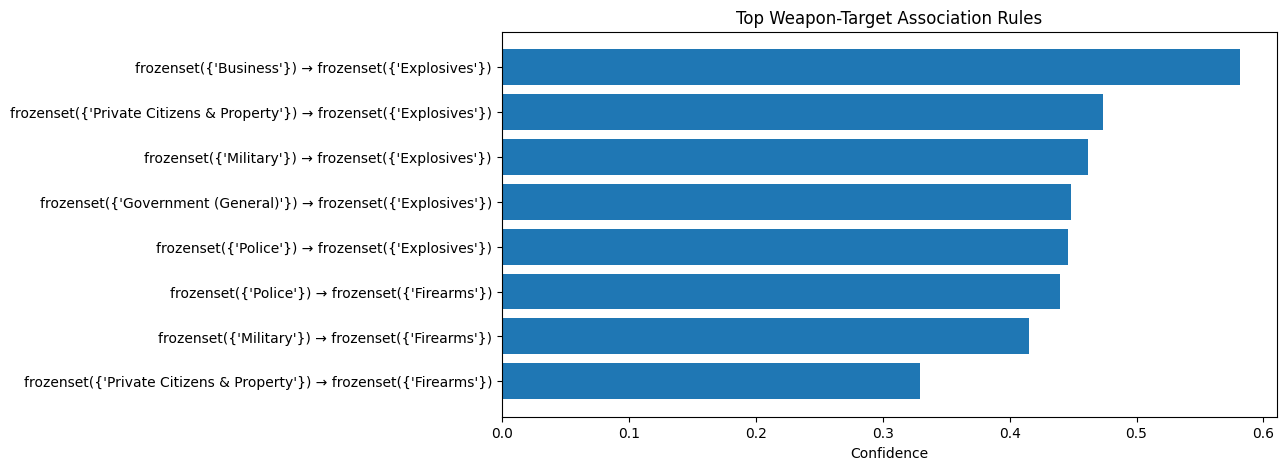

In [ ]:
# selecting top 10 rules
top_rules = rules.head(10)


plt.figure(figsize=(10,5))
plt.barh(range(len(top_rules)), top_rules['confidence'])

# setting labels (rule format: A → B)
plt.yticks(range(len(top_rules)),
           top_rules['antecedents'].astype(str) + " → " + top_rules['consequents'].astype(str))


plt.xlabel("Confidence")
plt.title("Top Weapon-Target Association Rules")


plt.gca().invert_yaxis()

plt.show()

1. **Explosives dominate across targets**

Most top rules involve explosives -> widely used weapon

2. **Business has the highest confidence rule**

Business -> Explosives is strongest -> high-impact targeting


3. **Civilians & Government also heavily linked to explosives**

Indicates preference for large scale disruptive attacks


4. **Firearms appear but with lower confidence**

Used in more specific situations (not universal like explosives)





**FP-GROWTH**

In [ ]:
from mlxtend.frequent_patterns import fpgrowth

# applying FP-Growth to find frequent itemsets
fp_items = fpgrowth(df_encoded, min_support=0.05, use_colnames=True)

# association rules
fp_rules = association_rules(fp_items, metric="confidence", min_threshold=0.3)

# sorting rules by confidence
fp_rules = fp_rules.sort_values(by='confidence', ascending=False)

# showing top 10 rules
fp_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

,antecedents,consequents,support,confidence,lift
7,(Business),(Explosives),0.066134,0.581354,1.142825
0,(Private Citizens & Property),(Explosives),0.113379,0.473443,0.930695
4,(Military),(Explosives),0.071137,0.461871,0.907946
6,(Government (General)),(Explosives),0.052479,0.448010,0.880698
3,(Police),(Explosives),0.060146,0.445932,0.876612
2,(Police),(Firearms),0.059348,0.440015,1.366050
5,(Military),(Firearms),0.063977,0.415380,1.289571
1,(Private Citizens & Property),(Firearms),0.078826,0.329158,1.021890


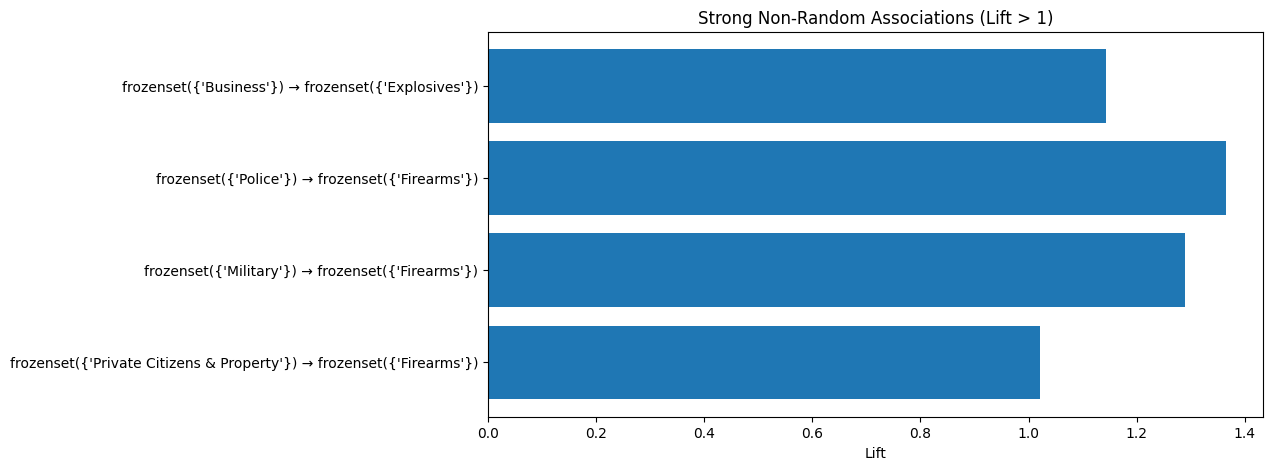

In [ ]:
# taking top rules where lift > 1 (strong relationships)
strong_rules = rules[rules['lift'] > 1].head(10)


plt.figure(figsize=(10,5))
plt.barh(range(len(strong_rules)), strong_rules['lift'])


plt.yticks(range(len(strong_rules)),
           strong_rules['antecedents'].astype(str) + " -> " + strong_rules['consequents'].astype(str))


plt.xlabel("Lift")
plt.title("Strong Non-Random Associations (Lift > 1)")

# putting highest value on top
plt.gca().invert_yaxis()


plt.show()

1. Police -> Firearms has highest lift
→ Strongest non-random relationship  (direct targeting pattern)

2. Military -> Firearms also highly significant



3. Business -> Explosives still appears important
 (Not just frequent, but also meaningful association)

4. Civilians -> Firearms has moderate lift
(Shows firearms are also used beyond security targets, but less strongly)

**K-Means clustering**

In [ ]:
# importing required libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
# make a copy of data
df_kmeans = df.copy()

# convert text to numbers
le1 = LabelEncoder()
le2 = LabelEncoder()

df_kmeans['weapon'] = le1.fit_transform(df_kmeans['weaptype1_txt'])
df_kmeans['target'] = le2.fit_transform(df_kmeans['targtype1_txt'])

In [ ]:

df_kmeans = df_kmeans[['weapon', 'target']]

# applying k-means
kmeans = KMeans(n_clusters=3, random_state=42)
df_kmeans['cluster'] = kmeans.fit_predict(df_kmeans)

In [ ]:
print(df_kmeans)

        weapon  target  cluster
0           10      13        0
1           10       5        1
2           10       7        1
3            2       5        1
4            5       5        1
...        ...     ...      ...
181686       4       9        0
181687       2       9        0
181688       5      13        0
181689       2       6        1
181690       2      19        2

[181691 rows x 3 columns]


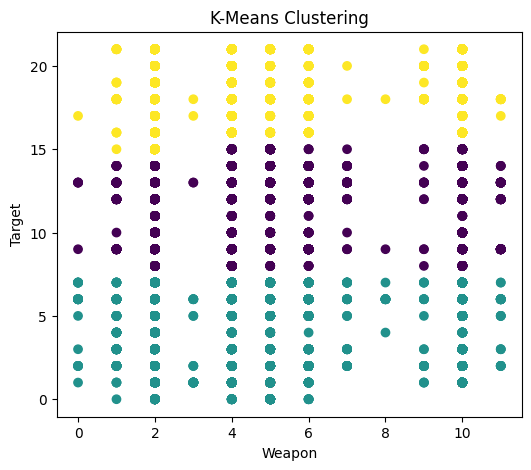

In [ ]:

plt.figure(figsize=(6,5))
plt.scatter(df_kmeans['weapon'], df_kmeans['target'], c=df_kmeans['cluster'])
plt.xlabel("Weapon")
plt.ylabel("Target")
plt.title("K-Means Clustering")
plt.show()

1. The model groups attacks into three different patterns.

2. Clustering is mainly based on target types -> Similar target categories fall into the same cluster.

3. Weapon types are spread across clusters -> The same weapon is used for  different targets, so weapon alone doesn’t define the group.

# **CONCLUSION**

In this project , unsupervised learning techniques were used to analyze patterns in global terrorism data. Apriori and FP-Growth were applied to identify relationships between weapon types and target types, revealing that attacks follow consistent patterns, such as explosives being widely used and firearms being more associated with security forces. FP-Growth provided similar results as Apriori but in a more efficient way. K-Means clustering was also tested, but it was less effective due to the categorical nature of the data. Overall, association rule mining methods proved to be the most suitable for this analysis.